# Stable Diffusion

https://github.com/huggingface/diffusers

https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5

**Stable Diffusion**은 텍스트(문장, 단어 등)를 입력하면 해당 내용을 바탕으로 이미지를 생성하는 **생성형 인공지능(Generative AI) 모델**이다.

2022년에 공개된 이 모델은 기존의 이미지 생성 AI와 달리 **Latent Diffusion Model(LDM)**이라는 구조를 사용한다.

주요 특징은 다음과 같다.

- **텍스트-투-이미지(Text-to-Image) 기능**: 사용자가 입력한 텍스트 프롬프트(예: "노을지는 바다")를 해석해 그에 맞는 이미지를 만들어낸다.
- **잠재 공간(Latent Space) 활용**: 이미지를 바로 생성하지 않고, 먼저 이미지를 저차원의 잠재 공간(latent space)으로 압축하여 이 공간에서 노이즈를 추가하거나 제거하는 방식으로 이미지를 생성한다. 이 과정은 Variational Autoencoder(VAE)와 같은 기법을 활용한다.
- **확산(Diffusion) 기법**: 원래 이미지를 점진적으로 노이즈로 바꿨다가, 이 노이즈를 다시 거꾸로 제거해가며 이미지를 복원하는 과정을 학습한다. 실제 생성 시에는 완전한 노이즈 상태에서 시작해, 입력된 텍스트에 맞는 이미지를 점차적으로 만들어낸다.
- **메모리 효율성**: 잠재 공간에서 연산을 수행하기 때문에, 기존 모델보다 훨씬 적은 메모리와 연산 자원으로도 고해상도 이미지를 생성할 수 있다. 일반 데스크탑이나 노트북에서도 실행이 가능하다.
- **오픈소스**: 누구나 자유롭게 사용할 수 있으며, 커스터마이징 및 연구·서비스 개발이 가능하다.

Stable Diffusion의 작동 원리를 간단히 설명하면 다음과 같다.

1. **학습 단계**  
   - 이미지와 그에 대한 설명(캡션) 쌍을 대량으로 학습한다.
   - 텍스트와 이미지의 특징을 잠재 공간에 매핑하는 방법을 익힌다.

2. **생성 단계**  
   - 사용자가 텍스트 프롬프트를 입력하면, 해당 텍스트의 의미를 잠재 공간에 반영한다.
   - 완전한 노이즈 상태에서 시작해, 여러 단계에 걸쳐 노이즈를 점차 제거하며 텍스트 의미에 맞는 이미지를 생성한다.
   - 마지막에 잠재 공간의 이미지를 실제 이미지로 복원한다.

이러한 구조 덕분에 Stable Diffusion은 **고품질 이미지 생성**, **빠른 처리 속도**, **낮은 하드웨어 요구사항**이라는 장점을 가진다.

수식적으로는, **확산 모델**은 다음과 같은 과정을 따른다.

- 순방향 과정:  

  $
  x_t = \sqrt{\alpha_t} x_{t-1} + \sqrt{1 - \alpha_t} \epsilon
  $

  여기서 $ x_t $는 t번째 단계의 이미지, $ \alpha_t $는 노이즈 스케줄, $ \epsilon $은 가우시안 노이즈이다.

- 역방향 과정(생성):

  $
  x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)
  $

  여기서 $ \epsilon_\theta $는 학습된 노이즈 예측 모델이다.

이 과정을 반복하면서 노이즈가 점점 줄고, 최종적으로 사람이 인식할 수 있는 이미지를 얻게 된다.

즉, **Stable Diffusion은 텍스트를 입력하면, 잠재 공간에서 노이즈를 점진적으로 제거하는 과정을 통해 고해상도 이미지를 효율적으로 생성하는 오픈소스 인공지능 모델**이다.

In [1]:
!pip install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 51.1 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# 디바이스 설정
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
# 모델 로드
from diffusers import StableDiffusionPipeline

model_id = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## 이미지 생성

  0%|          | 0/30 [00:00<?, ?it/s]

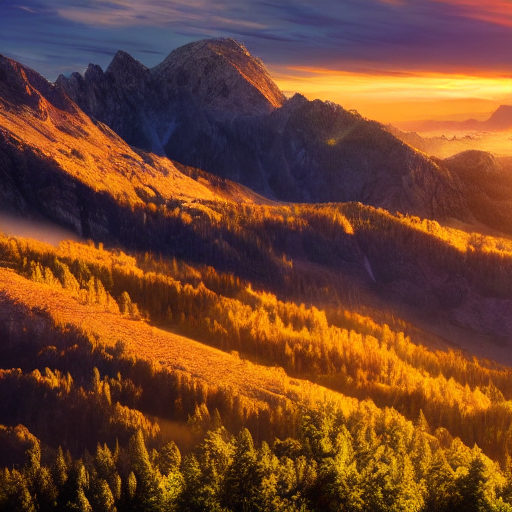

In [9]:
# 스타일 (photorealistic, oil painting, watercolor, pencil sketch, pixel art)
prompt = 'A serene landscape of mountains during sunrise, photorealistic'

result = pipe(
    prompt,
    num_inference_steps=30,  # 샘플링 스텝수 (스텝수가 많을수록 품질이 올라가지만 생성 시간이 늘어남)
    guidance_scale=7.5       # 텍스트-이미지 정합도(1~10). 높을수록 매칭 정도가 좋음 (일반적으로 7~8)
)

display(result.images[0])

## 배치 이미지 생성

In [10]:
prompts = [
    'A futuristic city skyline at sunset',
    'A portrait of a medieval knight in armor',
    'A colorful abstract painting with geometric shape'
]

result = pipe(
    prompts,
    num_inference_steps=30,
    guidance_scale=7.5,
    width=768,
    height=512
)

print(result.images)

  0%|          | 0/30 [00:00<?, ?it/s]

[<PIL.Image.Image image mode=RGB size=768x512 at 0x7B30C347F440>, <PIL.Image.Image image mode=RGB size=768x512 at 0x7B30C34A68A0>, <PIL.Image.Image image mode=RGB size=768x512 at 0x7B30C34A5370>]


In [11]:
# 이미지 저장
images = result.images

for idx, img in enumerate(images):
  filename = f'stable_diffusion_image_{idx}.png'
  img.save(filename)
  print(f'Saved: {filename}')

Saved: stable_diffusion_image_0.png
Saved: stable_diffusion_image_1.png
Saved: stable_diffusion_image_2.png
